In [1]:
import wandb
import pandas as pd
import numpy as np

import json

api = wandb.Api()

In [2]:
runs = api.runs(
    "pasqualedem/affex",
    filters={
        "$and": [
            {"group": "DCAMAblation"},
            {"tags": {"$nin": ["Broken"]}}
        ]
    }
)

In [3]:
def linearize_dict(d, parent_key='', sep='.'):
    """
    Linearizes a nested dictionary into a flat dictionary with keys in the format `key1.key2`.

    :param d: The dictionary to linearize.
    :param parent_key: The current key being processed (used for recursion).
    :param sep: The separator between keys.
    :return: A flattened dictionary.
    """
    items = []
    
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(linearize_dict(v, new_key, sep).items())
        else:
            items.append((new_key, v))
    
    return dict(items)

def get_runs_df(runs):
    runs_list = []
    for run in runs: 
        runs_list.append({
            **run.summary._json_dict,
            **linearize_dict({k: v for k,v in run.config.items()
            if not k.startswith('_')}),
            **linearize_dict(run.metadata if run.metadata else {}),
            **{"name": run.name, "id": run.id}
            })

    runs_df = pd.DataFrame(runs_list)
    return runs_df

In [4]:
runs_df = get_runs_df(runs)

In [5]:
paths = {}

for run in runs:
    print(run.id)
    art = [f for f in run.logged_artifacts() if "val_pascal5i_N1K5" in f.name][0]
    art.download()
    paths[run.id] = art.file()

iw7y6qcd


wandb:   1 of 1 files downloaded.  


behcy8jv


wandb:   1 of 1 files downloaded.  


oabl63rl


...

wandb:   1 of 1 files downloaded.  


bun2psp9


wandb:   1 of 1 files downloaded.  


e4fhfyeb


wandb:   1 of 1 files downloaded.  


In [6]:
runs_df = runs_df.join(pd.DataFrame.from_dict(paths, orient='index', columns=['scores_path']), on='id', how='inner')


In [7]:
def load_scores(row):
    with open(row['scores_path'], 'r') as f:
        data = json.load(f)
    return pd.DataFrame(data["data"], columns=data["columns"])

runs_df["scores"] = runs_df.apply(load_scores, axis=1)

In [8]:
step_baseline = 1000

step_values = set(runs_df["metric.n_steps"])
step_values = step_values - {step_baseline}

baseline = runs_df[runs_df["metric.n_steps"] == step_baseline].copy()

In [9]:
ablation_df = runs_df.drop(index=1)  # Drop the first row as it is not needed
ablation_df[["explainer.name", "metric.n_steps", "val_pascal5i_N1K5_dauc", "val_pascal5i_N1K5_iauc"]].sort_values(
    ["explainer.name", "metric.n_steps"],
)

,explainer.name,metric.n_steps,val_pascal5i_N1K5_dauc,val_pascal5i_N1K5_iauc
18,affinity,5,0.623903,0.830870
13,affinity,10,0.623994,0.853865
5,affinity,25,0.622731,0.866823
8,affinity,75,0.622469,0.871631
17,affinity,100,0.622337,0.872088
11,affinity,1000,0.622170,0.873262
19,integrated_gradients,5,0.834655,0.773223
21,random,5,0.814372,0.812695
14,random,10,0.829049,0.827038
0,random,25,0.832898,0.830839


In [10]:
cols = ["id", "explainer.name", "metric.n_steps", "scores"]

steps = {}
# Ensure 'explainer.name' is of type str in both DataFrames
cum_df = baseline[cols].copy()
cum_df["explainer.name"] = cum_df["explainer.name"].astype(str)
cum_df = cum_df.set_index("explainer.name")

for step_value in step_values:
	runs_step = runs_df[runs_df["metric.n_steps"] == step_value].copy()[cols]

	runs_step_fixed = runs_step.copy()
	runs_step_fixed["explainer.name"] = runs_step_fixed["explainer.name"].astype(str)

	cum_df = cum_df.join(
		runs_step_fixed.set_index("explainer.name"),
		rsuffix=f'_step_{step_value}',
		how="inner"
	)

cum_df

,id,metric.n_steps,scores,id_step_100,metric.n_steps_step_100,scores_step_100,id_step_5,metric.n_steps_step_5,scores_step_5,id_step_10,...,scores_step_10,id_step_75,metric.n_steps_step_75,scores_step_75,id_step_50,metric.n_steps_step_50,scores_step_50,id_step_25,metric.n_steps_step_25,scores_step_25
explainer.name,,,,,,,,,,,,,,,,,,,,,
random,dbbhikmb,1000,dauc_aucs iauc_aucs 0 0.872531 0.8...,jvkqmduw,100,dauc_aucs iauc_aucs 0 0.869679 0.8...,e4fhfyeb,5,dauc_aucs iauc_aucs 0 0.822668 0.8...,pipyyhbi,...,dauc_aucs iauc_aucs 0 0.861048 0.8...,hobjxf9z,75,dauc_aucs iauc_aucs 0 0.875651 0.8...,oabl63rl,50,dauc_aucs iauc_aucs 0 0.868839 0.8...,iw7y6qcd,25,dauc_aucs iauc_aucs 0 0.875358 0.8...
saliency,avydlx0x,1000,dauc_aucs iauc_aucs 0 0.820682 0.8...,h0evgj1u,100,dauc_aucs iauc_aucs 0 0.821221 0.8...,bun2psp9,5,dauc_aucs iauc_aucs 0 0.702278 0.8...,rgluzv61,...,dauc_aucs iauc_aucs 0 0.749351 0.8...,npaxhjyf,75,dauc_aucs iauc_aucs 0 0.817616 0.8...,3ba23auk,50,dauc_aucs iauc_aucs 0 0.808762 0.8...,aux6iy9b,25,dauc_aucs iauc_aucs 0 0.791943 0.8...
affinity,7ndflv4m,1000,dauc_aucs iauc_aucs 0 0.584412 0.9...,5kp4ozd5,100,dauc_aucs iauc_aucs 0 0.591718 0.9...,jhg70o2t,5,dauc_aucs iauc_aucs 0 0.564849 0.8...,wv70ynnh,...,dauc_aucs iauc_aucs 0 0.610625 0.8...,8xalry0a,75,dauc_aucs iauc_aucs 0 0.573381 0.9...,behcy8jv,50,dauc_aucs iauc_aucs 0 0.579165 0.9...,bd8ulgk8,25,dauc_aucs iauc_aucs 0 0.554272 0.9...


In [11]:
# Compute the mean for each DataFrame in the "scores" columns
score_cols = [x for x in cum_df.columns if "scores" in x]
means = {}
for col in score_cols:
	# Each entry is a DataFrame, so take the mean of each column in that DataFrame, then mean of those means
	means[col] = cum_df[col].apply(lambda df: df.values.mean() if isinstance(df, pd.DataFrame) else np.nan)
# Combine into a DataFrame for easier viewing
pd.DataFrame(means)

,scores,scores_step_100,scores_step_5,scores_step_10,scores_step_75,scores_step_50,scores_step_25
explainer.name,,,,,,,
random,NaN,NaN,NaN,NaN,NaN,NaN,NaN
saliency,NaN,NaN,NaN,NaN,NaN,NaN,NaN
affinity,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
def mse_score(row):
    """
    Calculate the mean squared error between the baseline scores and the scores at a specific step.
    """
    v = []
    for step in step_values:
        diff = ((row["scores"] - row[f"scores_step_{step}"])**2)
        # Remove NaN values
        diff = diff.dropna()
        # Calculate the mean squared error for each column
        diff = diff.mean()
        diff.index = [f"{col}_step_{step}".replace("aucs_", "mse_") for col in diff.index]
        v.append(diff)
    # v is a list of Series, merge into a single DataFrame row
    result = pd.concat(v, axis=0)
    result = result[sorted(result.index, key=sort_key)]
    return result

def sort_key(col_name):
    prefix, _, _, step = col_name.split('_')
    return (0 if prefix == 'dauc' else 1, int(step))
    
def mae_score(row):
    """
    Calculate the mean absolute error between the baseline scores and the scores at a specific step.
    """
    v = []
    for step in step_values:
        diff = (row["scores"] - row[f"scores_step_{step}"]).abs()
        # Remove NaN values
        diff = diff.dropna()
        # Calculate the mean squared error for each column
        diff = diff.mean()
        diff.index = [f"{col}_step_{step}".replace("aucs_", "mae_") for col in diff.index]
        v.append(diff)
    # v is a list of Series, merge into a single DataFrame row
    result = pd.concat(v, axis=0)
    result = result[sorted(result.index, key=sort_key)]
    return result

percentile = 0.95

def mae_percentile_bounded_score(row):
    """
    Calculate the mean absolute error between the baseline scores and the scores at a specific step.
    """
    v = []
    for step in step_values:
        diff = (row["scores"] - row[f"scores_step_{step}"]).abs()
        # Remove NaN values
        diff = diff.dropna()
        # Calculate the percentile of the absolute differences
        diff = diff.quantile(percentile)
        diff.index = [f"{col}_step_{step}".replace("aucs_", "mae-percentile_") for col in diff.index]
        v.append(diff)
    # v is a list of Series, merge into a single DataFrame row
    result = pd.concat(v, axis=0)
    result = result[sorted(result.index, key=sort_key)]
    return result
    

cum_df.apply(mse_score, axis=1)

,dauc_mse_step_5,dauc_mse_step_10,dauc_mse_step_25,dauc_mse_step_50,dauc_mse_step_75,dauc_mse_step_100,iauc_mse_step_5,iauc_mse_step_10,iauc_mse_step_25,iauc_mse_step_50,iauc_mse_step_75,iauc_mse_step_100
explainer.name,,,,,,,,,,,,
random,0.002043,0.001151,0.000953,0.000916,0.000897,0.000896,0.002266,0.001386,0.001194,0.001137,0.00116,0.001121
saliency,0.001168,0.000368,0.000092,0.000031,0.000018,0.000010,0.001368,0.000372,0.000104,0.000041,0.00002,0.000014
affinity,0.001906,0.000746,0.000222,0.000083,0.000043,0.000027,0.002163,0.000511,0.000075,0.000020,0.00001,0.000006


In [13]:
cum_df.apply(mae_score, axis=1)

,dauc_mae_step_5,dauc_mae_step_10,dauc_mae_step_25,dauc_mae_step_50,dauc_mae_step_75,dauc_mae_step_100,iauc_mae_step_5,iauc_mae_step_10,iauc_mae_step_25,iauc_mae_step_50,iauc_mae_step_75,iauc_mae_step_100
explainer.name,,,,,,,,,,,,
random,0.034048,0.022179,0.019591,0.019173,0.018896,0.018855,0.035797,0.023813,0.021236,0.020438,0.020503,0.020158
saliency,0.027080,0.014472,0.006942,0.004098,0.003082,0.002333,0.031451,0.015507,0.007610,0.004537,0.003251,0.002757
affinity,0.033269,0.020805,0.011140,0.006649,0.004875,0.003833,0.043872,0.020861,0.007668,0.003759,0.002517,0.001894


In [42]:
mae_perc_df = (cum_df.apply(mae_percentile_bounded_score, axis=1)*100).round(2).drop("random")
mae_perc_df.columns = pd.MultiIndex.from_tuples(
    [(x.split("_")[0], int(x.split("_")[-1])) for x in mae_perc_df.columns],
    names=["Metric", "N. Steps"]
)
dauc = mae_perc_df["dauc"]
dauc["Metric"] = "dauc"
iauc = mae_perc_df["iauc"]
iauc["Metric"] = "iauc"

mae_perc_df = pd.concat([dauc, iauc], axis=0)
mae_perc_df = mae_perc_df.reset_index()
mae_perc_df.set_index(["Metric", "explainer.name"], inplace=True, drop=True)
mae_perc_df

/tmp/ipykernel_621658/3732196954.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dauc["Metric"] = "dauc"
/tmp/ipykernel_621658/3732196954.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iauc["Metric"] = "iauc"


N. Steps                  5    10    25    50    75   100
Metric explainer.name                                    
dauc   saliency        6.44  3.85  1.91  1.16  0.86  0.66
       affinity        9.04  5.37  3.12  1.85  1.37  1.10
iauc   saliency        6.33  3.63  2.14  1.32  0.98  0.75
       affinity        6.64  3.22  1.34  0.77  0.59  0.46

In [43]:
from tabulate import tabulate

print(tabulate(mae_perc_df, headers='keys', tablefmt='latex_booktabs', floatfmt=".2f", showindex=True))

\begin{tabular}{lrrrrrr}
\toprule
                      &    5 &   10 &   25 &   50 &   75 &   100 \\
\midrule
 ('dauc', 'saliency') & 6.44 & 3.85 & 1.91 & 1.16 & 0.86 &  0.66 \\
 ('dauc', 'affinity') & 9.04 & 5.37 & 3.12 & 1.85 & 1.37 &  1.10 \\
 ('iauc', 'saliency') & 6.33 & 3.63 & 2.14 & 1.32 & 0.98 &  0.75 \\
 ('iauc', 'affinity') & 6.64 & 3.22 & 1.34 & 0.77 & 0.59 &  0.46 \\
\bottomrule
\end{tabular}


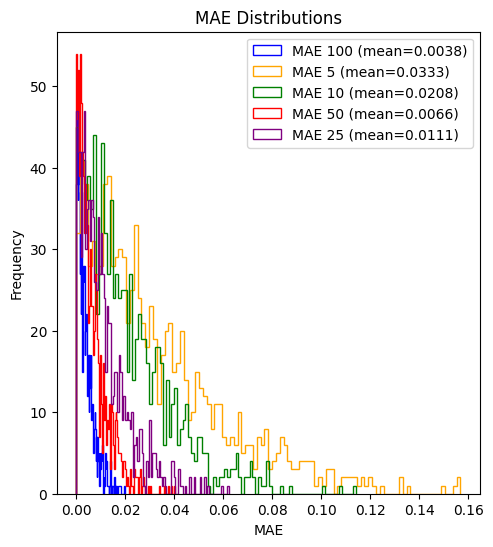

In [16]:
import matplotlib.pyplot as plt

aff_dfs = {col: cum_df.loc["affinity"][col]["dauc_aucs"].to_numpy().copy() for col in cum_df.columns if "scores" in col}

mae_100 = np.abs(aff_dfs["scores_step_100"] - aff_dfs["scores"])
mae_5 = np.abs(aff_dfs["scores_step_5"] - aff_dfs["scores"])
mae_10 = np.abs(aff_dfs["scores_step_10"] - aff_dfs["scores"])
mae_50 = np.abs(aff_dfs["scores_step_50"] - aff_dfs["scores"])
mae_25 = np.abs(aff_dfs["scores_step_25"] - aff_dfs["scores"])

# Remove NaN values from each array
mae_100 = mae_100[~np.isnan(mae_100)]
mae_5 = mae_5[~np.isnan(mae_5)]
mae_10 = mae_10[~np.isnan(mae_10)]
mae_50 = mae_50[~np.isnan(mae_50)]
mae_25 = mae_25[~np.isnan(mae_25)]

n_bins = 100
# plot mae distributions with mean in legend
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)

# Use step histtype for non-overlapping lines
plt.hist(mae_100, bins=n_bins, histtype='step', linewidth=1, label=f'MAE 100 (mean={mae_100.mean():.4f})', color='blue')
plt.hist(mae_5, bins=n_bins, histtype='step', linewidth=1, label=f'MAE 5 (mean={mae_5.mean():.4f})', color='orange')
plt.hist(mae_10, bins=n_bins, histtype='step', linewidth=1, label=f'MAE 10 (mean={mae_10.mean():.4f})', color='green')
plt.hist(mae_50, bins=n_bins, histtype='step', linewidth=1, label=f'MAE 50 (mean={mae_50.mean():.4f})', color='red')
plt.hist(mae_25, bins=n_bins, histtype='step', linewidth=1, label=f'MAE 25 (mean={mae_25.mean():.4f})', color='purple')

plt.xlabel('MAE')
plt.ylabel('Frequency')
plt.title('MAE Distributions')
plt.legend()
